# GAN 在双月牙数据上的对抗训练（对应书中 §12.2）

$$\min_G\max_D\;\mathbb{E}_{x\sim p_{\mathrm{data}}}[\log D(x)]
+\mathbb{E}_{z\sim\mathcal{N}(0,I)}[\log(1-D(G(z)))]$$

In [1]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

def sample_moons(n):
    n1, n2 = n // 2, n - n // 2
    t1 = torch.rand(n1) * math.pi
    t2 = torch.rand(n2) * math.pi
    x1 = torch.stack([torch.cos(t1), torch.sin(t1)], dim=1)
    x2 = torch.stack([1 - torch.cos(t2), -torch.sin(t2) + 0.5], dim=1)
    x = torch.cat([x1, x2]) + 0.05 * torch.randn(n, 2)
    return (x - x.mean(0)) / x.std(0)

data = sample_moons(4096)

In [2]:
zdim = 8
G = nn.Sequential(nn.Linear(zdim, 128), nn.SiLU(), nn.Linear(128, 128), nn.SiLU(), nn.Linear(128, 2))
D = nn.Sequential(nn.Linear(2, 128), nn.LeakyReLU(0.2), nn.Linear(128, 128), nn.LeakyReLU(0.2), nn.Linear(128, 1))

opt_g = torch.optim.Adam(G.parameters(), lr=1e-4, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(D.parameters(), lr=4e-4, betas=(0.5, 0.999))
bce = nn.BCEWithLogitsLoss()

for epoch in range(30001):
    x = data[torch.randint(0, len(data), (256,))]
    xf = G(torch.randn(256, zdim))
    loss_d = bce(D(x), torch.ones(256, 1)) + bce(D(xf.detach()), torch.zeros(256, 1))
    opt_d.zero_grad()
    loss_d.backward()
    opt_d.step()

    xf = G(torch.randn(256, zdim))
    loss_g = bce(D(xf), torch.ones(256, 1))
    opt_g.zero_grad()
    loss_g.backward()
    opt_g.step()

    if epoch % 5000 == 0:
        print(f"epoch {epoch:6d}   loss_D = {loss_d.item():.3f}   loss_G = {loss_g.item():.3f}")

epoch      0   loss_D = 1.406   loss_G = 0.736


epoch   5000   loss_D = 1.087   loss_G = 1.139


epoch  10000   loss_D = 1.138   loss_G = 1.111


epoch  15000   loss_D = 1.315   loss_G = 0.847


epoch  20000   loss_D = 1.322   loss_G = 0.847


epoch  25000   loss_D = 1.362   loss_G = 0.848


epoch  30000   loss_D = 1.321   loss_G = 0.776


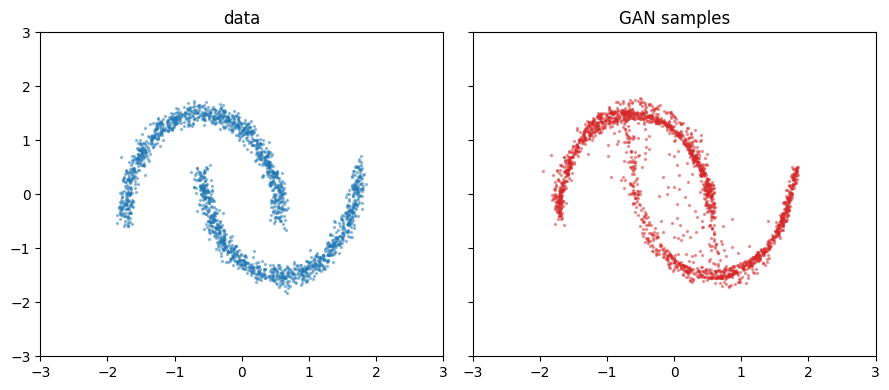

In [3]:
with torch.no_grad():
    gen = G(torch.randn(2000, zdim))

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
show = data[torch.randperm(len(data))[:2000]]
axes[0].scatter(show[:, 0], show[:, 1], s=2, alpha=0.4)
axes[0].set_title("data")
axes[1].scatter(gen[:, 0], gen[:, 1], s=2, alpha=0.4, color="tab:red")
axes[1].set_title("GAN samples")
for ax in axes:
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
plt.tight_layout(); plt.show()